# Intervention Effectiveness

Identify which intervention types and service combinations drive the most improvement in resident risk levels.

## 1. Problem Framing

**Business Problem:** Lighthouse Philippines provides services across 6 categories (Safety, Psychosocial, Education, Physical Health, Legal, Reintegration). Leadership needs to understand which intervention types drive the most resident improvement.

**Target variable:** `risk_improvement` — continuous (0–3), calculated as `initial_risk_score - current_risk_score`.

| Approach | Goal | Method |
|----------|------|--------|
| **Explanatory** | Understand *what drives* risk improvement | OLS Regression (statsmodels) |
| **Predictive** | Predict magnitude of improvement | GradientBoostingRegressor (sklearn Pipeline) |

**Important limitation:** With only 60 residents, we rely on cross-validation and remain cautious about overfitting.

## 2. Data Preparation & Exploration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")
SEED = 42
DATA_PATH = "../LighthouseData/"

# ── Load tables ──────────────────────────────────────────────────────────────
residents = pd.read_csv(DATA_PATH + "residents.csv")
plans = pd.read_csv(DATA_PATH + "intervention_plans.csv")
process_recordings = pd.read_csv(DATA_PATH + "process_recordings.csv")

for name, frame in [("residents", residents), ("plans", plans), ("process_recordings", process_recordings)]:
    print(f"  {name:25s} → {frame.shape[0]:>5} rows, {frame.shape[1]:>3} cols")

# ── Target variable ──────────────────────────────────────────────────────────
risk_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
residents['initial_risk_score'] = residents['initial_risk_level'].map(risk_map)
residents['current_risk_score'] = residents['current_risk_level'].map(risk_map)
residents['risk_improvement'] = residents['initial_risk_score'] - residents['current_risk_score']

# ── Intervention plan aggregates ─────────────────────────────────────────────
plan_counts = plans.groupby('resident_id').size().reset_index(name='plan_count')

plan_cat_counts = (
    plans.groupby(['resident_id', 'plan_category']).size()
    .unstack(fill_value=0).reset_index()
)
cat_col_map = {col: col.lower().replace(' ', '_') + '_plan_count'
               for col in plan_cat_counts.columns if col != 'resident_id'}
plan_cat_counts = plan_cat_counts.rename(columns=cat_col_map)

plans['is_achieved'] = (plans['status'] == 'Achieved').astype(int)
pct_achieved = plans.groupby('resident_id')['is_achieved'].mean().reset_index(name='pct_achieved')

# Parse services_provided (comma-separated)
services_exploded = plans.assign(
    service=lambda df: df['services_provided'].str.split(',')
).explode('service')
services_exploded['service'] = services_exploded['service'].str.strip()

service_counts = (
    services_exploded.groupby(['resident_id', 'service']).size()
    .unstack(fill_value=0).reset_index()
)
svc_col_map = {col: col.lower().replace(' ', '_') + '_count'
               for col in service_counts.columns if col != 'resident_id'}
service_counts = service_counts.rename(columns=svc_col_map)

for svc_name, flag_name in [('Caring', 'has_caring'), ('Healing', 'has_healing'),
                              ('Teaching', 'has_teaching'), ('Legal Services', 'has_legal')]:
    svc_residents = services_exploded[services_exploded['service'] == svc_name]['resident_id'].unique()
    plan_counts[flag_name] = plan_counts['resident_id'].isin(svc_residents).astype(int)

plan_features = (plan_counts
    .merge(plan_cat_counts, on='resident_id', how='left')
    .merge(pct_achieved, on='resident_id', how='left')
    .merge(service_counts, on='resident_id', how='left')
    .fillna(0))

# ── Process recording aggregates ─────────────────────────────────────────────
emotion_map = {'Distressed':1, 'Angry':2, 'Withdrawn':3, 'Sad':4,
               'Anxious':5, 'Calm':6, 'Hopeful':7, 'Happy':8}
process_recordings['start_score'] = process_recordings['emotional_state_observed'].map(emotion_map)
process_recordings['end_score'] = process_recordings['emotional_state_end'].map(emotion_map)
process_recordings['emotion_change'] = process_recordings['end_score'] - process_recordings['start_score']

pr_agg = process_recordings.groupby('resident_id').agg(
    session_count=('recording_id', 'count'),
    avg_session_duration=('session_duration_minutes', 'mean'),
    pct_individual_sessions=('session_type', lambda x: (x == 'Individual').mean()),
    avg_emotion_change=('emotion_change', 'mean')
).reset_index()

# ── Resident-level features ──────────────────────────────────────────────────
abuse_cols = [c for c in residents.columns if c.startswith('sub_cat_')]
residents['abuse_type_count'] = residents[abuse_cols].apply(
    lambda row: sum(str(v).strip().lower() == 'true' for v in row), axis=1)
residents['has_special_needs'] = residents['has_special_needs'].apply(
    lambda x: 1 if str(x).strip().lower() == 'true' else 0)

resident_features = residents[['resident_id', 'initial_risk_score', 'case_category',
                                'abuse_type_count', 'has_special_needs', 'risk_improvement']].copy()

# ── Merge all ────────────────────────────────────────────────────────────────
df = (resident_features
    .merge(plan_features, on='resident_id', how='left')
    .merge(pr_agg, on='resident_id', how='left')
    .fillna(0))

y = df['risk_improvement']
X = df.drop(columns=['resident_id', 'risk_improvement'])
X = pd.get_dummies(X, columns=['case_category'], drop_first=True, dtype=int)

print(f"\nFinal feature matrix: {X.shape[0]} rows, {X.shape[1]} features")
X.head()

  residents                 →    60 rows,  49 cols
  plans                     →   180 rows,  11 cols
  process_recordings        →  2819 rows,  15 cols

Final feature matrix: 60 rows, 23 features


,initial_risk_score,abuse_type_count,has_special_needs,plan_count,has_caring,has_healing,has_teaching,has_legal,education_plan_count,physical_health_plan_count,...,healing_count,legal_services_count,teaching_count,session_count,avg_session_duration,pct_individual_sessions,avg_emotion_change,case_category_Foundling,case_category_Neglected,case_category_Surrendered
0,4,0,1,3,1,1,1,1,1,1,...,3,2,2,106,69.433962,0.669811,1.905660,0,1,0
1,2,2,0,3,1,1,1,1,1,1,...,1,2,1,51,68.176471,0.568627,1.823529,0,0,1
2,2,1,0,3,1,1,1,1,1,1,...,1,2,2,53,69.452830,0.566038,1.849057,0,0,1
3,3,1,0,3,1,1,1,1,1,1,...,1,1,2,57,69.596491,0.543860,1.877193,0,1,0
4,2,2,0,3,1,1,1,1,1,1,...,3,1,3,18,65.611111,0.888889,2.000000,0,0,1


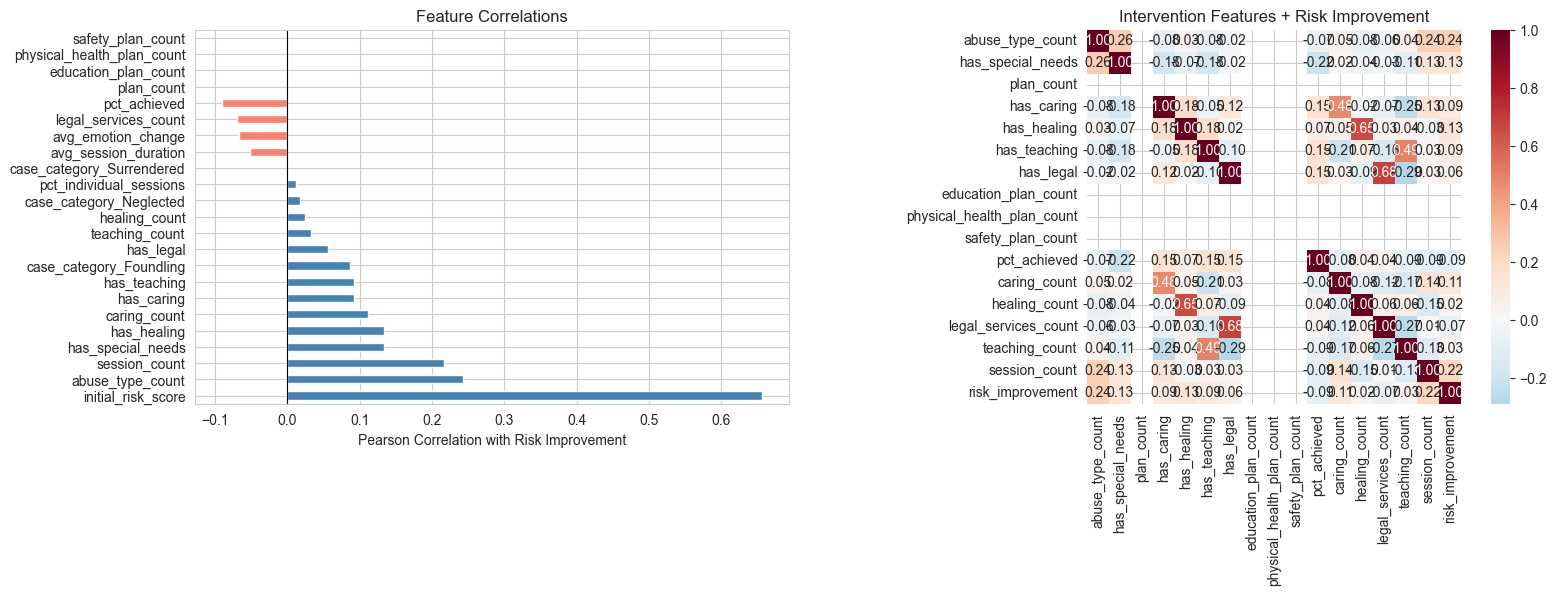

In [2]:
# ── EDA: correlations with target ────────────────────────────────────────────
corr_with_target = X.corrwith(y).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_with_target.plot(kind='barh', ax=axes[0],
    color=['steelblue' if v >= 0 else 'salmon' for v in corr_with_target])
axes[0].set_xlabel("Pearson Correlation with Risk Improvement")
axes[0].set_title("Feature Correlations")
axes[0].axvline(0, color='black', linewidth=0.8)

intervention_cols = [c for c in X.columns if 'plan_count' in c or 'has_' in c or '_count' in c or 'pct_achieved' in c]
corr_matrix = X[intervention_cols].join(y).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], square=True)
axes[1].set_title("Intervention Features + Risk Improvement")
plt.tight_layout()
plt.show()

## 3. Modeling

### 3a. Explanatory Model — OLS Regression

In [3]:
# ── OLS Regression + VIF ─────────────────────────────────────────────────────
X_exp = sm.add_constant(X.copy())
ols = sm.OLS(y, X_exp).fit()
print(ols.summary())

# VIF
vif = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)
print("\nVariance Inflation Factors:")
print(vif.to_string(index=False))

# Significant coefficients
coef_df = pd.DataFrame({
    'Feature': ols.params.index, 'Coefficient': ols.params.values,
    'p-value': ols.pvalues.values
}).query("Feature != 'const'").sort_values('Coefficient', ascending=False)

sig = coef_df[coef_df['p-value'] < 0.10].sort_values('p-value')
if len(sig) > 0:
    print("\nSignificant predictors (p < 0.10):")
    print(sig.to_string(index=False))
else:
    print("\nNo features reached p < 0.10. Expected with n=60.")

                            OLS Regression Results                            
Dep. Variable:       risk_improvement   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     2.566
Date:                Mon, 06 Apr 2026   Prob (F-statistic):            0.00601
Time:                        20:36:19   Log-Likelihood:                -50.048
No. Observations:                  60   AIC:                             140.1
Df Residuals:                      40   BIC:                             182.0
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
initial_risk_score  

### 3b. Predictive Model — sklearn Pipeline

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# ── Train/test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), X.columns.tolist())],
    remainder='passthrough'
)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree (d=3)': DecisionTreeRegressor(max_depth=3, random_state=SEED),
    'DecisionTree (d=5)': DecisionTreeRegressor(max_depth=5, random_state=SEED),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                                    learning_rate=0.1, random_state=SEED),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'Model': name, 'CV MAE': -cv_scores.mean(),
        'Test MAE': mean_absolute_error(y_test, y_pred),
        'Test R2': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values('CV MAE')
print("Model comparison:")
print(results_df.to_string(index=False))

# ── Best model + permutation importance ──────────────────────────────────────
best_pipeline = Pipeline([('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                         learning_rate=0.1, random_state=SEED))])
best_pipeline.fit(X_train, y_train)

perm_imp = permutation_importance(best_pipeline, X_test, y_test,
                                   n_repeats=30, random_state=SEED, scoring='neg_mean_absolute_error')
perm_df = pd.DataFrame({
    'Feature': X.columns, 'Importance': perm_imp.importances_mean
}).sort_values('Importance', ascending=False)

print("\nTop features by permutation importance:")
print(perm_df.head(10).to_string(index=False))

Model comparison:
             Model   CV MAE  Test MAE   Test R2
DecisionTree (d=3) 0.607675  0.773148 -0.230093
DecisionTree (d=5) 0.613889  0.750000 -0.868000
  GradientBoosting 0.675349  0.718542 -0.140159
  LinearRegression 0.846253  0.773673 -0.098606

Top features by permutation importance:
                Feature  Importance
     initial_risk_score    0.239834
   legal_services_count    0.023217
   avg_session_duration    0.017857
       abuse_type_count    0.012507
          healing_count    0.011434
case_category_Neglected    0.005971
      has_special_needs    0.001749
             plan_count    0.000000
             has_caring    0.000000
            has_healing    0.000000


## 4. Evaluation

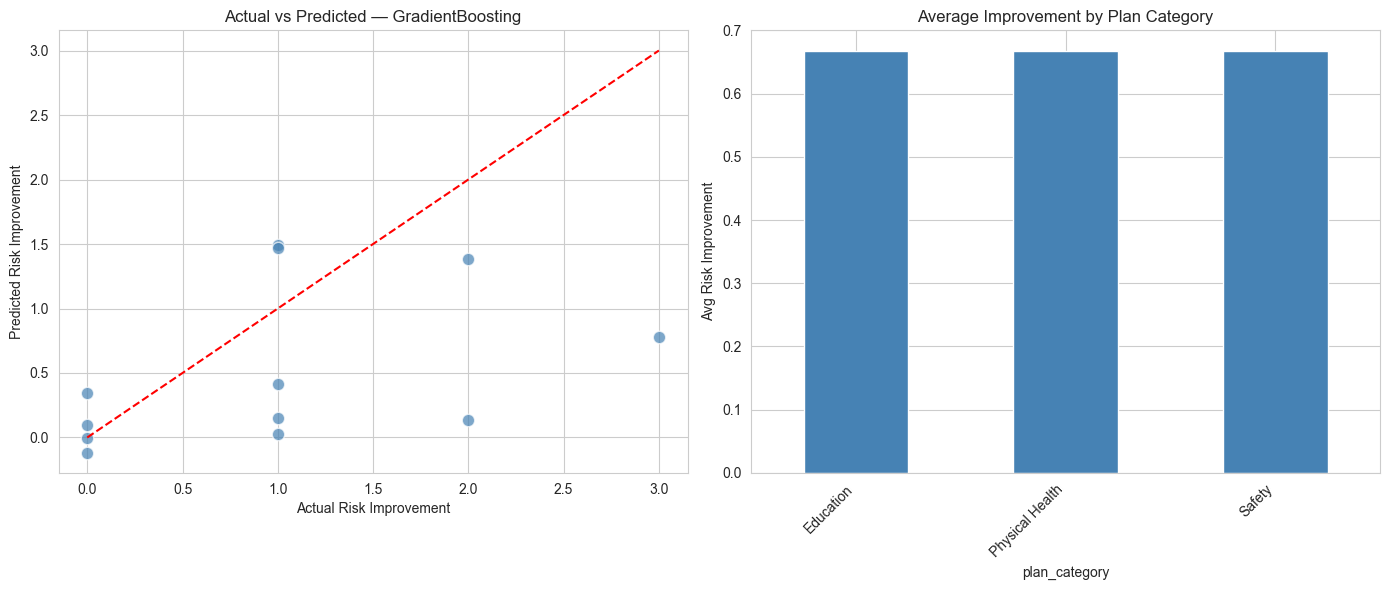

GradientBoosting Test MAE: 0.7185
GradientBoosting Test R²:  -0.1402


In [5]:
# ── Actual vs predicted + business summary ───────────────────────────────────
y_pred_best = best_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_best, alpha=0.7, color='steelblue', edgecolor='white', s=80)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel("Actual Risk Improvement")
axes[0].set_ylabel("Predicted Risk Improvement")
axes[0].set_title("Actual vs Predicted — GradientBoosting")

# Average improvement by plan category and service
plan_cat_improvement = plans.merge(residents[['resident_id', 'risk_improvement']], on='resident_id')
cat_summary = plan_cat_improvement.groupby('plan_category')['risk_improvement'].mean().sort_values(ascending=False)
cat_summary.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_ylabel("Avg Risk Improvement")
axes[1].set_title("Average Improvement by Plan Category")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"GradientBoosting Test MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"GradientBoosting Test R²:  {r2_score(y_test, y_pred_best):.4f}")

## 5. Causal and Relationship Analysis

**Critical caveat:** Interventions are **not randomly assigned** — they are assigned based on each resident's needs. This creates selection bias.

A positive coefficient on "safety_plan_count" does NOT mean giving more safety plans causes improvement. It may reflect that residents who need safety plans have more room to improve.

Despite this, the **relative** effectiveness across intervention types is informative, and `pct_achieved` measures execution quality (less subject to selection bias).

## 6. Deployment Notes

**Integration:** Intervention effectiveness insights are displayed on the **Reports & Analytics** admin page. The dashboard shows which intervention categories and service types drive the most improvement.

**Endpoint:** `GET /api/ml/intervention-effectiveness` returns a ranked list of intervention types by predicted risk improvement.

**How it works:**
1. The OLS coefficients identify which plan categories have the strongest association with risk improvement
2. The Gradient Boosting model provides predicted improvement scores for different intervention combinations
3. The admin dashboard displays a bar chart of intervention effectiveness and highlights high-impact service types

**Retraining:** Re-run as new intervention plan outcomes are recorded.

## 7. Summary

**Key Findings:**
- The OLS model identifies which intervention categories and services are most associated with risk improvement
- Plan achievement rate (`pct_achieved`) is a meaningful predictor — execution quality matters
- Session characteristics (count, duration, emotion change) contribute to the predictive model

**Limitations:**
- n=60 is very small for ML — all metrics have wide confidence intervals
- Selection bias: interventions are assigned based on need, not randomly
- These results provide a starting point for further investigation